<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec27_Boot_camp_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Handwritten Digit Recognition using ANN

## 📌 Introduction

In this project, we build an Artificial Neural Network (ANN) to classify handwritten digits (0–9).  
The goal is to train a model that can correctly identify digits from grayscale images.

We use the famous MNIST dataset, which contains 7 thousands of handwritten digit images.  
This is one of the most fundamental datasets in Deep Learning and is often considered the "Hello World" of Neural Networks.

---

## 📊 About the Dataset

- Total Images: 70,000
- Training Images: 60,000
- Testing Images: 10,000
- Image Size: 28 × 28 pixels
- Color Format: Grayscale
- Number of Classes: 10 (digits 0–9)

Each image is a 28×28 matrix where:
- Each cell represents a pixel value.
- Pixel values range from 0 (black) to 255 (white).

---

## 🎯 Why Do We Study This Dataset?

1. It is simple and beginner-friendly.
2. It helps understand how neural networks work.
3. It demonstrates image classification.
4. It teaches preprocessing steps clearly.
5. It is widely used for benchmarking ML models.

This dataset helps us understand:
- How images are represented numerically
- How neural networks learn patterns
- How classification problems are solved

---

## ⚙️ Project Steps

1. Load the dataset
2. Explore the data (shape, sample images)
3. Normalize pixel values
4. Encode labels (One-hot encoding)
5. Build ANN model
6. Train the model
7. Evaluate performance
8. Test predictions

---

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
#60000 + 60000  , 10000+10000



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training Data Shape:", X_train.shape) #(60000, 28, 28) 60k photos, pixel*pixel
print("Testing Data Shape:", X_test.shape) #photo 10000

print("Training Labels Shape:", y_train.shape) #digit like list
print("Testing Labels Shape:", y_test.shape) #digit like list

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)
Training Labels Shape: (60000,)
Testing Labels Shape: (10000,)


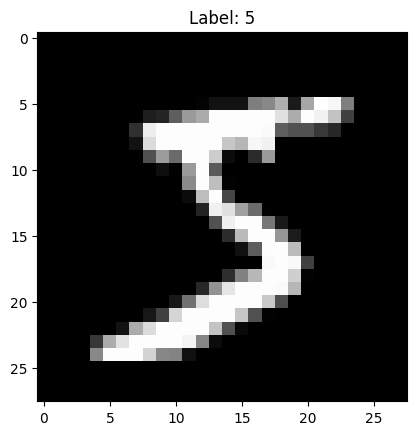

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

## 🔄 Why Do We Normalize the Data?

Original pixel values range from 0 to 255.

Neural networks perform better when input values are small and within a similar range.

We divide pixel values by 255 to scale them between 0 and 1.

Benefits:
- Faster training
- Stable gradient updates
- Better convergence

---

In [ ]:
print("Max value before normalization:", X_train.max())
print("Min value before normalization:", X_train.min())

Max value before normalization: 255
Min value before normalization: 0


In [ ]:
# Normalize
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
print("Max value after normalization:", X_train.max())
print("Min value after normalization:", X_train.min())

Max value after normalization: 1.0
Min value after normalization: 0.0


In [ ]:
print("Before Encoding:", y_train[0])

Before Encoding: 5


## 🔢 Why Do We Use One-Hot Encoding?

The output layer uses Softmax activation for multi-class classification.

Instead of labels like:
5

We convert them to:
[0 0 0 0 0 1 0 0 0 0]

This allows the model to:
- Compare predicted probabilities
- Calculate categorical crossentropy loss

---

In [ ]:

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
print("After Encoding:", y_train[0])

After Encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 📏 Why Do We Flatten the Image?

Each image is 28 × 28 (2D matrix).

ANN models accept only 1D input.

So we convert:
28 × 28 → 784 features

This means:
Each pixel becomes one input neuron.

Flattening converts the 2D image into a 1D vector so it can be processed by fully connected layers.

---

## 🏗️ Model Architecture

Input Layer: 784 neurons  
Hidden Layer 1: 128 neurons (ReLU)  
Hidden Layer 2: 64 neurons (ReLU)  
Output Layer: 10 neurons (Softmax)  

---

In [ ]:



# Build ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)), #784 flatten
    Dense(128, activation='relu'), #hidden layer-1
    Dense(64, activation='relu'), #hidden layer-2
    Dense(10, activation='softmax') #output layer
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy', #10 classess
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc) #maximum
print("Test error:", test_loss) #minimum

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8774 - loss: 0.4214 - val_accuracy: 0.9634 - val_loss: 0.1259
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9679 - loss: 0.1049 - val_accuracy: 0.9690 - val_loss: 0.1014
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9795 - loss: 0.0655 - val_accuracy: 0.9710 - val_loss: 0.0944
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9837 - loss: 0.0498 - val_accuracy: 0.9763 - val_loss: 0.0813
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0396 - val_accuracy: 0.9735 - val_loss: 0.0888
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9736 - val_loss: 0.0967
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9914 - loss: 0.0254 - val_accuracy: 0.9780 - val_loss: 0.0821
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9925 - loss: 0.0221 -

In [ ]:
print("Before Flatten Shape:", X_train.shape)

X_train_flat = X_train.reshape(60000, 784)

print("After Flatten Shape:", X_train_flat.shape)

Before Flatten Shape: (60000, 28, 28)
After Flatten Shape: (60000, 784)


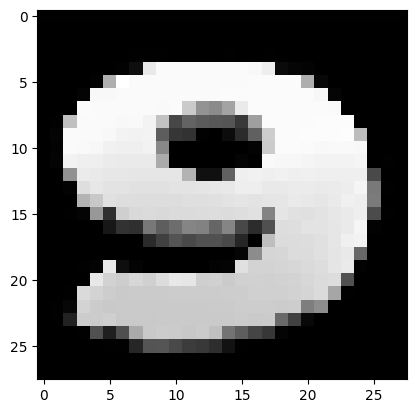

In [ ]:
import numpy as np
import cv2 #computer vision , image library
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/content/9digit.jpeg", cv2.IMREAD_GRAYSCALE)

# Resize to 28x28
img = cv2.resize(img, (28, 28)) #??? training data 28*28

# Invert if needed (MNIST is white digit on black background)

# Normalize
img = img / 255.0 #1 to 0

# Reshape for ANN
img = img.reshape(1, 28, 28)

plt.imshow(img.reshape(28,28), cmap='gray')
plt.show()

In [ ]:
prediction = model.predict(img)

print("Raw Output:", prediction)
print("Predicted Digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Raw Output: [[2.4522600e-07 1.4339521e-19 4.6430311e-14 1.9071131e-06 1.4473353e-17
  2.3478115e-01 4.0330009e-12 1.3446278e-14 2.1042801e-08 7.6521665e-01]]
Predicted Digit: 9


## 📈 Expected Outcome

After training, the model should achieve around 96–98% accuracy.

This project demonstrates:
- Image preprocessing
- ANN architecture
- Forward propagation
- Backpropagation
- Multi-class classification

---

## 🚀 Conclusion

This project helps us understand how Artificial Neural Networks can classify images by learning patterns from pixel values.

It forms the foundation for more advanced models like Convolutional Neural Networks (CNNs).

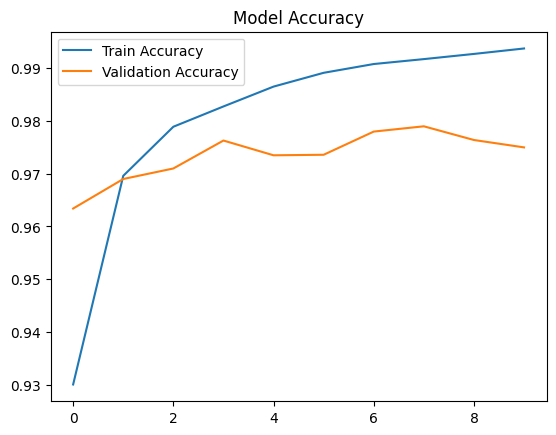

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy') #line graph
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') #line graph
plt.legend()
plt.title("Model Accuracy")
plt.show()



If both lines close → good model

If validation drops → overfitting


## 📊 Model Accuracy Analysis

### 🔵 Training Accuracy
- Starts around **93%**
- Gradually increases with each epoch
- Ends around **99.3%**

This indicates that the ANN is learning the training data very effectively.

---

### 🟠 Validation Accuracy
- Starts around **96.5%**
- Improves to approximately **97.8–97.9%**
- Shows slight fluctuations in later epochs

This suggests that the model generalizes well to unseen data.

---

## 🧠 Is This Overfitting?

👉 **Yes, but only mild overfitting is observed.**

At the final epochs:
- **Training Accuracy ≈ 99.3%**
- **Validation Accuracy ≈ 97.6–97.9%**
- **Accuracy Gap ≈ 1.5–2%**

This means:
- The model fits the training data very well.
- Generalization to new data is slightly lower but still strong.

⚠️ This level of overfitting is **not dangerous** and is **normal for ANN models** applied to image data.

---

## 🔍 Important Observations

### 1️⃣ Validation Accuracy Plateaus Early
- Validation accuracy stabilizes around **epoch 3–4**.
- This indicates that the model learns the most important patterns early during training.

👉 Additional epochs provide only marginal improvement in validation performance.

---

### 2️⃣ Training Accuracy Continues to Improve
- Training accuracy keeps increasing even after validation accuracy plateaus.
- This suggests the model begins to memorize finer details of the training data.

👉 This behavior explains the small gap between training and validation accuracy.

---

## ✅ Conclusion
Overall, the ANN model performs very well with high accuracy and stable learning behavior.  
The slight overfitting observed does not significantly impact performance and the model generalizes effectively to unseen data.